Name: Anirudh Kavle
<br>
Github Username: Anirudh-Kavle
<br>
Email: kavle@usc.edu
<br>
USC ID: 6327535963

## 1. Combined Cycle Power Plant Data Set

### (a) Download Data

Package imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf
from statsmodels.stats.anova import anova_lm
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import MinMaxScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_squared_error as mse

sns.set_theme(style="whitegrid")
pd.set_option("display.precision", 4)

Get the Cycle Power Plant Data Set

I got the data as a zip file the professor shared on Dropbox. It contains the UCI Combined Cycle Power Plant dataset (https://archive.ics.uci.edu/ml/datasets/Combined+Cycle+Power+Plant), and I unzipped it into `../data/CCPP/`. `Folds5x2_pp.xlsx` has five sheets, all shuffled copies of the same data, so per the task I only use Sheet1. The columns in the file are named `AT`, `V`, `AP`, `RH` and `PE`; the task text calls temperature *T* and the output *EP*.

In [2]:
df = pd.read_excel("../data/CCPP/Folds5x2_pp.xlsx", sheet_name="Sheet1")
P = ["AT", "V", "AP", "RH"]
df.head()

,AT,V,AP,RH,PE
0,14.96,41.76,1024.07,73.17,463.26
1,25.18,62.96,1020.04,59.08,444.37
2,5.11,39.40,1012.16,92.14,488.56
3,20.86,57.32,1010.24,76.64,446.48
4,10.82,37.50,1009.23,96.62,473.90


### (b) Exploring the data

#### i. rows and columns

In [3]:
print("Rows:", df.shape[0], "| Columns:", df.shape[1])
print("Missing values:", df.isna().sum().sum())
print("Exact duplicate rows:", df.duplicated().sum())
print("Rows with RH > 100%:", (df.RH > 100).sum(), "| max RH:", df.RH.max())

Rows: 9568 | Columns: 5
Missing values: 0
Exact duplicate rows: 41
Rows with RH > 100%: 55 | max RH: 100.16


The data has 9,568 rows and 5 columns.

Each row is one hour of the plant running at full load sometime between 2006 and 2011, and the values are hourly averages. The columns are four ambient variables (the predictors) and the plant's output (the response):

| Column | Meaning | Unit | Role |
|---|---|---|---|
| AT | Ambient temperature | °C | Predictor |
| V | Exhaust vacuum | cm Hg | Predictor |
| AP | Ambient pressure | mbar | Predictor |
| RH | Relative humidity | % | Predictor |
| PE | Net hourly electrical energy output | MW | Response |

No missing values. There are 41 exact duplicate rows and 55 rows with RH slightly above 100% (max 100.16%). The data doesn't show why either happens or that these rows are wrong, so I keep all of them.

#### ii. pairwise scatterplots of all the variables

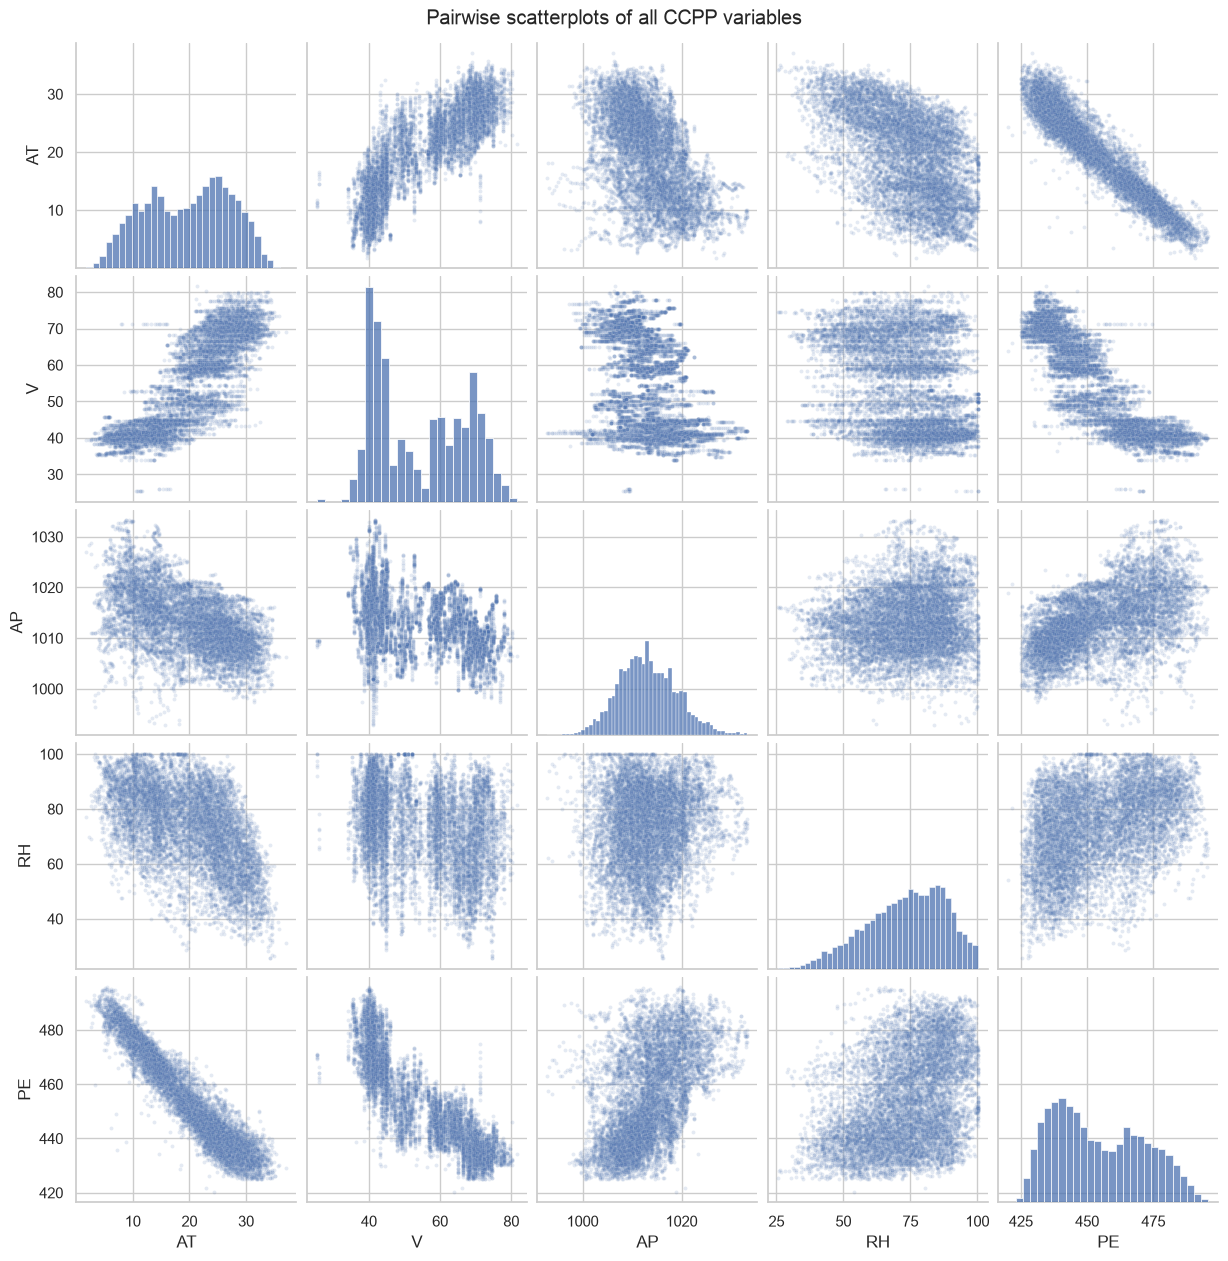

,AT,V,AP,RH,PE
AT,1.000,0.844,-0.508,-0.543,-0.948
V,0.844,1.000,-0.414,-0.312,-0.870
AP,-0.508,-0.414,1.000,0.100,0.518
RH,-0.543,-0.312,0.100,1.000,0.390
PE,-0.948,-0.870,0.518,0.390,1.000


In [4]:
g = sns.pairplot(df, diag_kind="hist", plot_kws={"alpha": 0.15, "s": 8})
g.figure.suptitle("Pairwise scatterplots of all CCPP variables", y=1.01)
plt.show()
df.corr().round(3)

- AT vs PE (r = -0.948) is strong, close to linear and negative. Output drops about 2 MW per °C and levels off a little at the hot end. AT has the strongest pairwise association with PE.
- V vs PE (r = -0.870) is also strongly negative, but V comes in vertical bands, which looks like the plant running in a few distinct operating regimes. V is also highly correlated with AT (r = 0.844), so their individual relationships with PE are difficult to separate from the pairwise plots alone.
- AP vs PE (r = 0.518) is a moderate positive trend and RH vs PE (r = 0.390) a weak one, both with a lot of scatter. Both are negatively correlated with AT (r = -0.508 and -0.543), which may partly explain their positive pairwise associations with PE. The multiple regression in (d) and (e) helps separate these relationships.
- AT, V and PE are bimodal, RH is left-skewed and piles up near 100%, and AP is roughly bell-shaped. There's also a small cluster of 13 points at V $\approx$ 25, well away from every other V value.

#### iii. mean, the median, range, first and third quartiles, and interquartile ranges

In [5]:
s = df.describe().T
summary = pd.DataFrame({"mean": s["mean"],
                        "median": df.median(), 
                        "min": s["min"], 
                        "max": s["max"],
                        "range": s["max"] - s["min"], 
                        "Q1": s["25%"], "Q3": s["75%"],
                        "IQR": s["75%"] - s["25%"]
                    })
summary.round(3)

,mean,median,min,max,range,Q1,Q3,IQR
AT,19.651,20.345,1.81,37.11,35.30,13.510,25.72,12.210
V,54.306,52.080,25.36,81.56,56.20,41.740,66.54,24.800
AP,1013.259,1012.940,992.89,1033.30,40.41,1009.100,1017.26,8.160
RH,73.309,74.975,25.56,100.16,74.60,63.328,84.83,21.502
PE,454.365,451.550,420.26,495.76,75.50,439.750,468.43,28.680


RH's mean (73.3) is below its median (75.0), which fits its left skew. AP is tightly concentrated, with an IQR of 8.16 mbar around a mean of 1,013.26 mbar. Because the units differ, the IQRs don't say which variable is more variable. They do show what an unscaled Euclidean distance sees, though: in raw units V and RH spread the most (IQRs 24.8 and 21.5) and AP the least, so V and RH will dominate raw KNN distances in part 1(i).

### (c) Simple Linear Regression

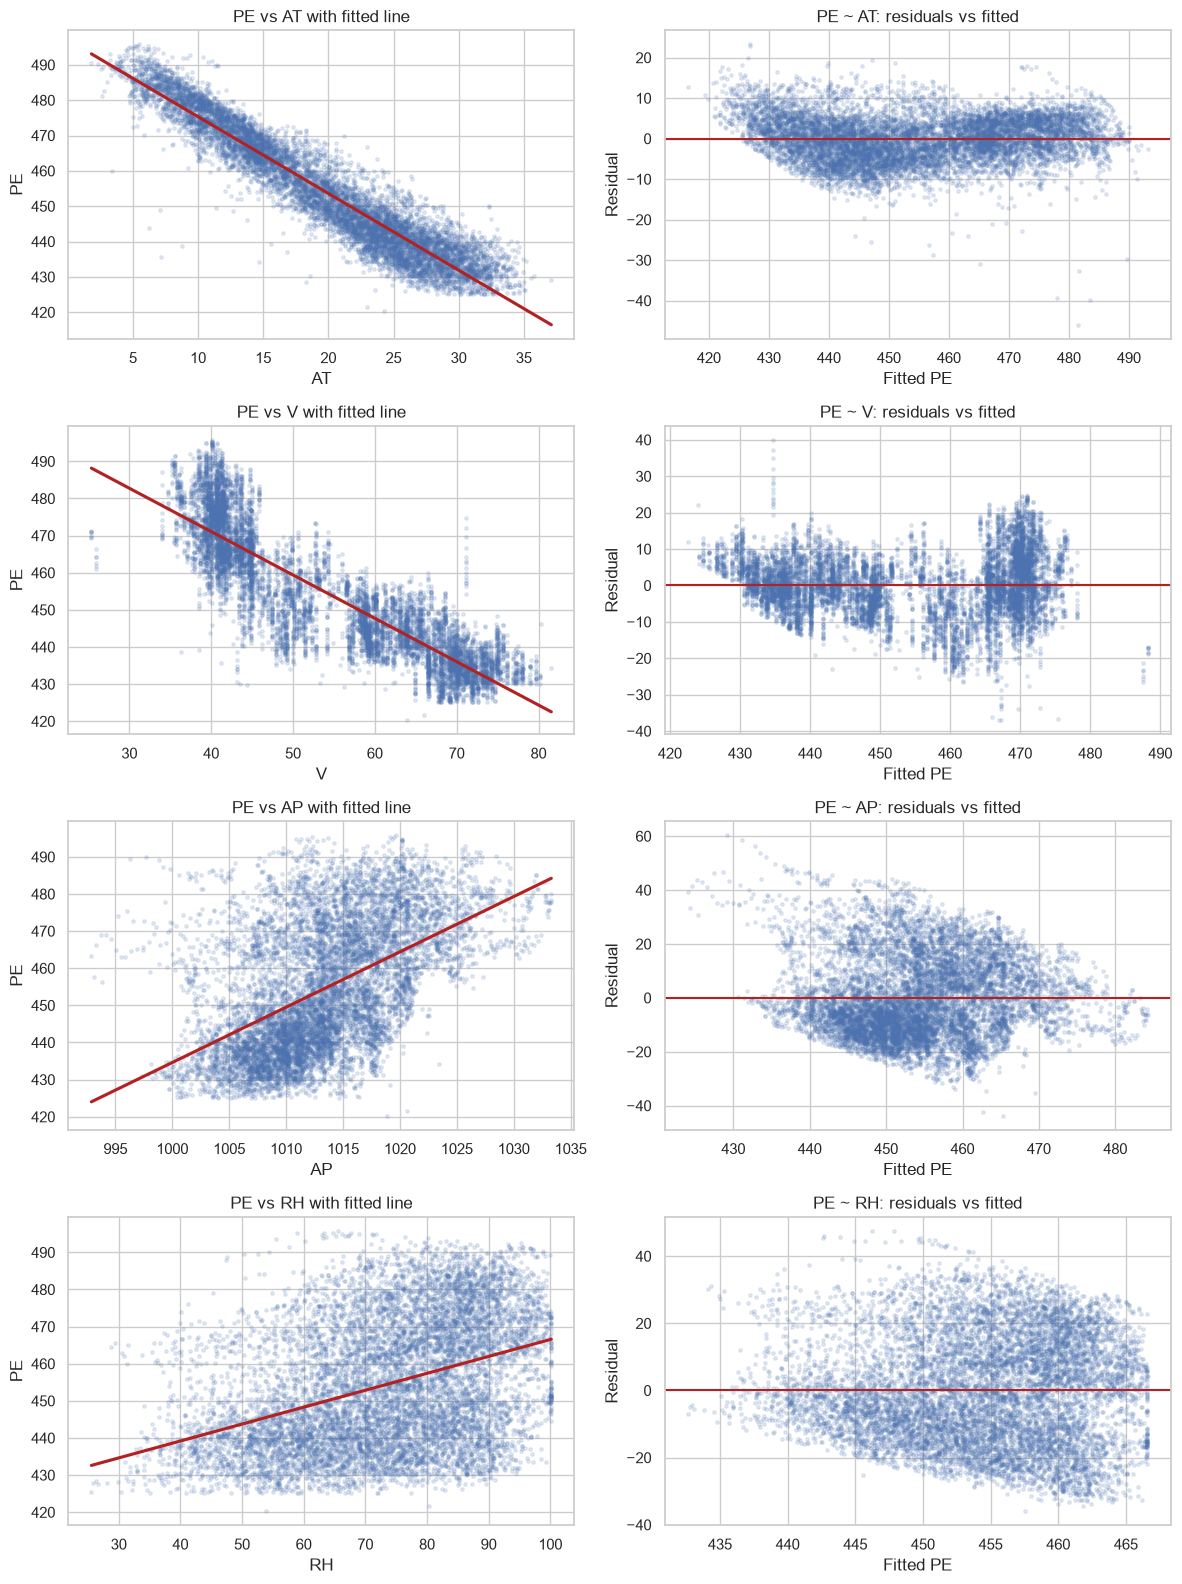

,intercept,slope,SE,t,p-value,R2,|stud. resid| > 3,Cook's D > 4/n,max Cook's D
predictor,,,,,,,,,
AT,497.0341,-2.1713,0.0074,-291.7152,0.0,0.8989,42,416,0.0143
V,517.8015,-1.1681,0.0068,-172.4015,0.0,0.7565,33,423,0.0032
AP,-1055.2610,1.4899,0.0251,59.2962,0.0,0.2688,30,300,0.0082
RH,420.9618,0.4557,0.0110,41.3987,0.0,0.1519,2,249,0.0021


In [6]:
simple, rows = {}, []
fig, axes = plt.subplots(4, 2, figsize=(12, 16))
for i, p in enumerate(P):
    m = smf.ols(f"PE ~ {p}", data=df).fit()
    simple[p] = m
    infl = m.get_influence()
    cook = infl.cooks_distance[0]
    rows.append({"predictor": p, "intercept": m.params["Intercept"], "slope": m.params[p],
                 "SE": m.bse[p], "t": m.tvalues[p], "p-value": m.pvalues[p], "R2": m.rsquared,
                 "|stud. resid| > 3": (np.abs(infl.resid_studentized_external) > 3).sum(),
                 "Cook's D > 4/n": (cook > 4 / len(df)).sum(), "max Cook's D": cook.max()})
    sns.regplot(data=df, x=p, y="PE", ax=axes[i, 0], ci=None,
                scatter_kws={"alpha": 0.15, "s": 6}, line_kws={"color": "firebrick"})
    axes[i, 0].set_title(f"PE vs {p} with fitted line")
    axes[i, 1].scatter(m.fittedvalues, m.resid, alpha=0.15, s=6)
    axes[i, 1].axhline(0, color="firebrick")
    axes[i, 1].set(title=f"PE ~ {p}: residuals vs fitted", xlabel="Fitted PE", ylabel="Residual")
fig.tight_layout()
plt.show()
pd.DataFrame(rows).set_index("predictor")

In [7]:
low_v = df[df.V < 30]
print(f"{len(low_v)} rows with V < 30: V from {low_v.V.min()} to {low_v.V.max()}, "
      f"PE from {low_v.PE.min()} to {low_v.PE.max()}")

13 rows with V < 30: V from 25.36 to 25.88, PE from 460.97 to 471.19


Each model is $PE = \beta_0 + \beta_1 X + \epsilon$. Reading off the slopes:

- AT: each extra °C goes with 2.17 MW less output ($R^2$ = 0.899).
- V: each extra cm Hg of exhaust vacuum goes with 1.17 MW less ($R^2$ = 0.757).
- AP: each extra mbar goes with 1.49 MW more ($R^2$ = 0.269). The intercept of -1055 would be the output at zero pressure, far outside the data, so it means nothing by itself.
- RH: each extra percentage point of humidity goes with 0.46 MW more ($R^2$ = 0.152).

All four associations are statistically significant. Every |t| is above 40, and every p-value is below $10^{-300}$ (they're smaller than the smallest number a double can hold, so they print as 0.0), so we reject $H_0: \beta_1 = 0$ in all four models. With n = 9,568, even fairly small effects can be statistically significant, so practical strength matters too. The $R^2$ values differ a lot: AT alone explains about 90% of the variation in PE, compared with about 15% for RH.

The plots back this up. For AT the points hug the line, but the residuals curve instead of forming a flat band, so the relationship is slightly nonlinear (more on that in (f)). The V residuals come in vertical stripes (the same banding in V seen in the pairplot), plus an isolated group at fitted PE $\approx$ 488 with residuals around -17 to -27. Those are the 13 rows with V $\approx$ 25.4. AP and RH pick up a trend, but their residuals are far more spread out and show visible structure. All four models have the same response, so wider residual spread here directly means a lower $R^2$.

On outliers: externally studentized residuals flag 42, 33, 30 and 2 points with |t| > 3 in the four models, but none of them is very influential. The largest Cook's distance in any model is 0.014, nowhere near the usual cutoff of 1. The stricter 4/n rule (about 0.0004) flags a few hundred points per model, but with 9,568 rows no single point moves a fitted line noticeably, and nothing suggests these are recording errors. The most unusual rows are the 13 with V between 25.36 and 25.88 (PE 461-471 MW). They're far from every other V value, but that alone doesn't make them errors. So I wouldn't remove any points for these regressions.

### (d) Multiple Regression

In [8]:
multi = smf.ols("PE ~ AT + V + AP + RH", data=df).fit()
print(multi.summary())

                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.929
Model:                            OLS   Adj. R-squared:                  0.929
Method:                 Least Squares   F-statistic:                 3.114e+04
Date:                Sat, 26 Sep 2026   Prob (F-statistic):               0.00
Time:                        23:52:20   Log-Likelihood:                -28088.
No. Observations:                9568   AIC:                         5.619e+04
Df Residuals:                    9563   BIC:                         5.622e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    454.6093      9.749     46.634      0.0

$$\widehat{PE} = 454.609 - 1.9775\,AT - 0.2339\,V + 0.0621\,AP - 0.1581\,RH$$

$R^2$ = 0.9287 (adjusted 0.9287) and the overall F-test has p $\approx$ 0. The coefficients are now partial effects: the change in output for a one-unit change in one predictor with the other three held fixed.

We can reject $H_0: \beta_j = 0$ for all four predictors at $\alpha = 0.05$: AT (t = -129.3), RH (t = -37.9), V (t = -32.1) and AP (t = 6.56, p = 5.5e-11). AT has by far the largest |t|. AP has the smallest, but it's still significant.

### (e) 1c Compare to 1d

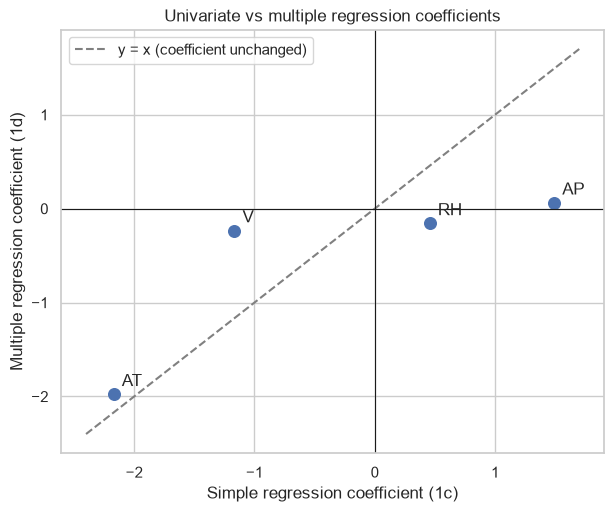

,simple (1c),multiple (1d)
AT,-2.1713,-1.9775
V,-1.1681,-0.2339
AP,1.4899,0.0621
RH,0.4557,-0.1581


In [9]:
comp = pd.DataFrame({"simple (1c)": [simple[p].params[p] for p in P],
                     "multiple (1d)": [multi.params[p] for p in P]}, index=P)

fig, ax = plt.subplots(figsize=(7, 5.5))
ax.scatter(comp["simple (1c)"], comp["multiple (1d)"], s=70)
for name, (x, y) in comp.iterrows():
    ax.annotate(name, (x, y), xytext=(6, 6), textcoords="offset points")
lim = [-2.4, 1.7]
ax.plot(lim, lim, ls="--", color="gray", label="y = x (coefficient unchanged)")
ax.axhline(0, color="k", lw=0.8)
ax.axvline(0, color="k", lw=0.8)
ax.set(xlabel="Simple regression coefficient (1c)", ylabel="Multiple regression coefficient (1d)",
       title="Univariate vs multiple regression coefficients")
ax.legend()
plt.show()
comp.round(4)

The coefficients change a lot. AT's shrinks by only about 9%, V's by 80% and AP's by 96%, and RH's actually changes sign. The overall fit improves only a little: $R^2$ goes from 0.899 with AT alone to 0.929 with all four predictors.

This comes from correlation among the predictors. A simple regression slope captures the *total* association between a predictor and PE, including whatever moves along with that predictor. A multiple regression slope is the association with the other predictors held fixed.

- AT sits close to the y = x line, so its estimated coefficient changes relatively little after adjusting for the other predictors.
- V is strongly correlated with AT (r = 0.844), and its coefficient shrinks substantially after adjustment, from -1.168 to -0.234, though it stays significant (t = -32.1).
- AP is negatively correlated with AT (r = -0.508), and its coefficient falls from 1.490 in the simple regression to 0.062 after adjustment.
- RH is negatively correlated with AT (r = -0.543). Its simple coefficient is positive (+0.456), but after adjusting for the other predictors it becomes negative (-0.158). This sign reversal shows how strongly the estimated RH association depends on whether the other predictors are controlled for.

### (f) Nonlinear Association

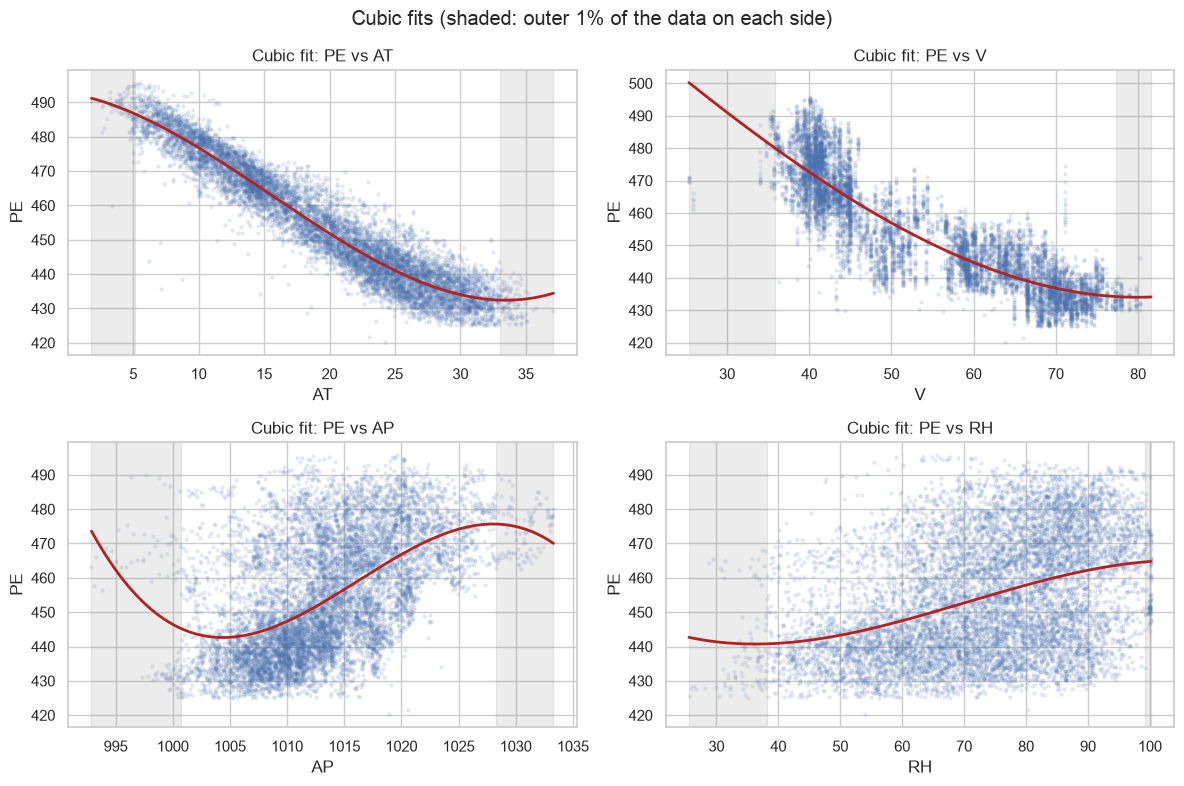

,R2 linear,R2 cubic,p(X^2),p(X^3),joint F,joint p
predictor,,,,,,
AT,0.8989,0.9119,3.3118e-231,3.6522e-110,701.9673,3.4784e-285
V,0.7565,0.7750,8.9770e-131,1.3735e-02,393.3141,7.0403e-165
AP,0.2688,0.2975,2.1927e-46,2.1233e-67,195.8856,4.2091e-84
RH,0.1519,0.1537,1.0139e-01,1.4403e-05,10.1889,3.7996e-05


In [10]:
rows = []
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, p in zip(axes.ravel(), P):
    w = pd.DataFrame({"PE": df.PE, "X": df[p] - df[p].mean()})  # raw AP**3 is ~1e9, so center first
    lin = smf.ols("PE ~ X", data=w).fit()
    cub = smf.ols("PE ~ X + I(X**2) + I(X**3)", data=w).fit()
    F, pF = anova_lm(lin, cub).loc[1, ["F", "Pr(>F)"]]
    rows.append({"predictor": p, "R2 linear": lin.rsquared, "R2 cubic": cub.rsquared,
                 "p(X^2)": cub.pvalues["I(X ** 2)"], "p(X^3)": cub.pvalues["I(X ** 3)"],
                 "joint F": F, "joint p": pF})
    xs = np.linspace(w.X.min(), w.X.max(), 300)
    ax.scatter(df[p], df.PE, alpha=0.1, s=5)
    ax.plot(xs + df[p].mean(), cub.predict(pd.DataFrame({"X": xs})), color="firebrick", lw=2)
    lo, hi = df[p].quantile([0.01, 0.99])
    ax.axvspan(df[p].min(), lo, color="gray", alpha=0.15)
    ax.axvspan(hi, df[p].max(), color="gray", alpha=0.15)
    ax.set(title=f"Cubic fit: PE vs {p}", xlabel=p, ylabel="PE")
fig.suptitle("Cubic fits (shaded: outer 1% of the data on each side)")
fig.tight_layout()
plt.show()
pd.DataFrame(rows).set_index("predictor")

Yes. All four predictors show statistically significant evidence of nonlinear association. However, the improvement in $R^2$ is much smaller for RH (0.18 percentage points) than for AT, V and AP.

For each predictor I compared the cubic model with the straight line using a joint F-test of $H_0: \beta_2 = \beta_3 = 0$. The joint p-value is tiny every time; the largest is 3.8e-5, for RH. Going from linear to cubic raises $R^2$ by 1.30 percentage points for AT, 1.85 for V and 2.87 for AP. Term by term, at least one of $X^2$ and $X^3$ is significant for every predictor (for RH only $X^3$ is, with p = 1.4e-5; its $X^2$ term has p = 0.10).

Two notes on method:
- I centered each predictor before squaring and cubing it. Raw AP is about 1,013, so $AP^3$ is on the order of $10^9$, and AP, $AP^2$ and $AP^3$ move almost in lockstep, which makes the raw fit numerically unreliable. Centering is just a reparametrization, so the fitted curve, $R^2$ and joint test stay the same.
- I went with the joint F-test over the individual $X^2$ and $X^3$ p-values because those depend on how the polynomial is written (for example, whether X is centered), while the joint test doesn't.

In the plot, the shaded tails hold only 1% of the data on each side, so the curves there are poorly pinned down. Near V $\approx$ 25 the only data are the 13 rows from (c), at 461-471 MW, and the curve passes well above them at about 500 MW, so its rise there comes from the cubic extending the steep slope of the dense data, not from those points. The upturn in AT above about 33 °C and the rise in AP below 1,000 mbar each rest on fewer than 100 points, so they're weakly supported too. In the bulk of the data, output levels off at high temperature, which matches the curved AT residuals from (c).

### (g) Interactions of Predictors

In [11]:
inter = smf.ols("PE ~ (AT + V + AP + RH)**2", data=df).fit()  # all main effects + all pairwise products
print(inter.summary().tables[1])
print(f"R2 = {inter.rsquared:.4f} (main effects only: {multi.rsquared:.4f})")

                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    685.7825     78.640      8.721      0.000     531.631     839.934
AT            -4.3470      2.373     -1.832      0.067      -8.999       0.305
V             -7.6749      1.351     -5.682      0.000     -10.323      -5.027
AP            -0.1524      0.077     -1.983      0.047      -0.303      -0.002
RH             1.5709      0.773      2.031      0.042       0.055       3.087
AT:V           0.0210      0.001     23.338      0.000       0.019       0.023
AT:AP          0.0018      0.002      0.752      0.452      -0.003       0.006
AT:RH         -0.0052      0.001     -6.444      0.000      -0.007      -0.004
V:AP           0.0068      0.001      5.135      0.000       0.004       0.009
V:RH           0.0008      0.000      1.716      0.086      -0.000       0.002
AP:RH         -0.0016      0.001     -2.125      0.0

Yes. Four of the six pairwise interactions are significant at $\alpha = 0.05$: AT:V, AT:RH, V:AP and AP:RH. AT:AP (p = 0.45) and V:RH (p = 0.086) aren't. $R^2$ goes from 0.9287 to 0.9363.

- AT:V has by far the largest |t| among the interaction terms (t = 23.3). Its positive coefficient means that as V increases, the estimated negative association between AT and PE becomes less steep, and similarly the estimated V association becomes less negative as AT increases.
- The main-effect p-values in this model (e.g. AT, p = 0.067) don't mean AT is unimportant. With interactions in the model, each main-effect coefficient is the estimated slope when the other variables it interacts with are zero (for AT, zero vacuum, pressure and humidity), which is far outside the data.

### (h) Improvement

In [12]:
d2 = df.copy()
for p in P:
    d2[p + "2"] = d2[p] ** 2
train, test = train_test_split(d2, test_size=0.3, random_state=42)
print("train rows:", len(train), "| test rows:", len(test))


def fit(terms):
    return smf.ols("PE ~ " + " + ".join(terms), data=train).fit()


m_lin = fit(P)
terms = P + ["AT:V", "AT:AP", "AT:RH", "V:AP", "V:RH", "AP:RH", "AT2", "V2", "AP2", "RH2"]
m_full = fit(terms)

children = {"AT": ["AT:V", "AT:AP", "AT:RH", "AT2"],
            "V": ["AT:V", "V:AP", "V:RH", "V2"],
            "AP": ["AT:AP", "V:AP", "AP:RH", "AP2"],
            "RH": ["AT:RH", "V:RH", "AP:RH", "RH2"]}

while True:
    m = fit(terms)
    removable = [t for t in terms if not any(c in terms for c in children.get(t, []))]
    worst = max(removable, key=lambda t: m.pvalues[t])
    if m.pvalues[worst] < 0.05:
        break
    print(f"drop {worst:<5} p = {m.pvalues[worst]:.4f}")
    terms.remove(worst)
m_red = m
print("kept:", " + ".join(terms))

models = {"Linear (main effects)": m_lin, "Full quadratic + interactions": m_full,
          "Reduced (after elimination)": m_red}
lm_mse = pd.DataFrame.from_dict({name: {"terms": len(m.params) - 1,
                                         "train MSE": mse(train.PE, m.fittedvalues),
                                         "test MSE": mse(test.PE, m.predict(test))}
                                  for name, m in models.items()}, orient="index")
lm_mse

train rows: 6697 | test rows: 2871
drop V:RH  p = 0.8674
drop V2    p = 0.6077
drop V:AP  p = 0.3578
kept: AT + V + AP + RH + AT:V + AT:AP + AT:RH + AP:RH + AT2 + AP2 + RH2


,terms,train MSE,test MSE
Linear (main effects),4,20.5808,21.2399
Full quadratic + interactions,14,17.8878,18.6473
Reduced (after elimination),11,17.8908,18.6600


Yes. Adding interaction and quadratic terms brings test MSE down from 21.24 to 18.66, about 12% lower.

I split the data once at random, 70/30 (`random_state=42`, which gives 6,697 training rows and 2,871 test rows). Every model is fit on the training rows only; the test rows are only used for test MSE.

1. Linear model: `PE ~ AT + V + AP + RH`.
2. Full model: 4 main effects + 6 pairwise interactions + 4 squares (14 terms).
3. Reduced model: backward elimination on the full model using training-set p-values. Each round drops the single term with the largest p-value above 0.05, except that a main effect is never dropped while an interaction or square containing it is still in the model (the hierarchy principle, which is the "be careful about interaction terms" part). This removed V:RH (p = 0.867), $V^2$ (p = 0.608) and V:AP (p = 0.358), leaving

$$PE \sim AT + V + AP + RH + AT{\cdot}V + AT{\cdot}AP + AT{\cdot}RH + AP{\cdot}RH + AT^2 + AP^2 + RH^2$$

Dropping one term at a time matters here. In the full model AT:AP has p = 0.197 and the V main effect has p = 0.267, so removing everything above 0.05 in one go would lose both. V has to stay because AT:V is in the model, and AT:AP becomes clearly significant (p = 0.0015) once V:AP is out. The two share AP and partly compete for the same signal.

| Model | Train MSE | Test MSE |
|---|---|---|
| Linear (main effects) | 20.58 | 21.24 |
| Reduced (after elimination) | 17.89 | 18.66 |

The reduced model does as well as the full one (test MSE 18.66 vs 18.65) with three fewer terms. Test MSE is only slightly above train MSE for all three models, so there's no obvious sign of severe overfitting on this split. The nonlinear and interaction effects from (f) and (g) also improve predictions on held-out data, since both expanded models beat the linear one on test MSE.

### (i) KNN

In [13]:
Xtr, Xte, ytr, yte = train[P], test[P], train.PE, test.PE
ks = np.arange(1, 101)
scalings = {"raw": None, "min-max normalized": MinMaxScaler()}
curves, best = {}, {}
for name, scaler in scalings.items():
    tr_err, te_err = [], []
    for k in ks:
        knn = KNeighborsRegressor(n_neighbors=k)
        model = knn if scaler is None else make_pipeline(scaler, knn)  # scaler is fit on training rows only
        model.fit(Xtr, ytr)
        tr_err.append(mse(ytr, model.predict(Xtr)))
        te_err.append(mse(yte, model.predict(Xte)))
    curves[name] = (np.array(tr_err), np.array(te_err))
    i = int(np.argmin(te_err))
    best[name] = {"best k": ks[i], "train MSE": tr_err[i], "test MSE": te_err[i]}
best = pd.DataFrame.from_dict(best, orient="index")
best

,best k,train MSE,test MSE
raw,5,10.6008,15.7268
min-max normalized,4,8.4543,14.2913


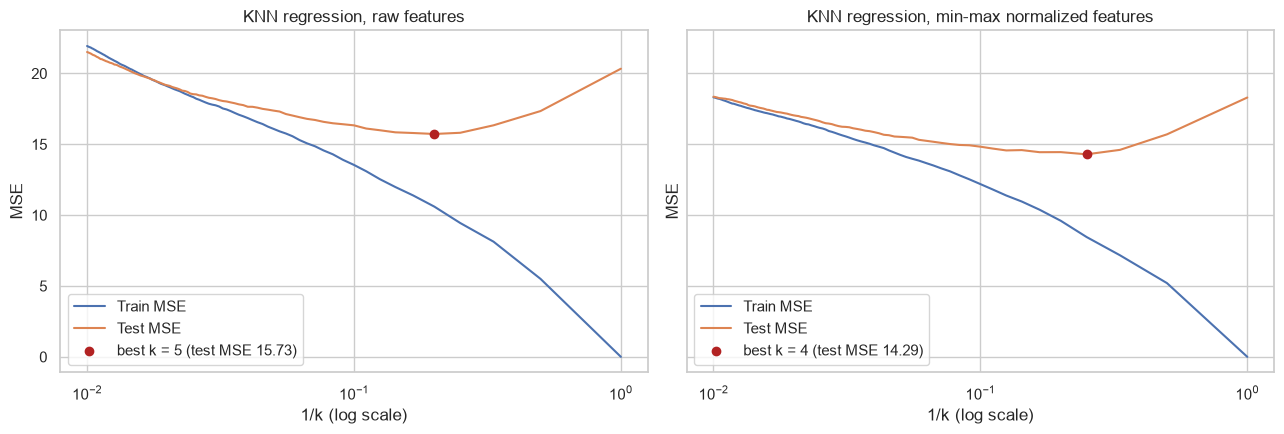

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharey=True)
for ax, name in zip(axes, ["raw", "min-max normalized"]):
    tr_err, te_err = curves[name]
    i = int(np.argmin(te_err))
    ax.plot(1 / ks, tr_err, label="Train MSE")
    ax.plot(1 / ks, te_err, label="Test MSE")
    ax.scatter(1 / ks[i], te_err[i], color="firebrick", zorder=5,
               label=f"best k = {ks[i]} (test MSE {te_err[i]:.2f})")
    ax.set(xscale="log", title=f"KNN regression, {name} features", xlabel="1/k (log scale)", ylabel="MSE")
    ax.legend()
fig.tight_layout()
plt.show()

In [15]:
# E||xi - xj||^2 = 2 * sum of feature variances, so a feature's share is var / total
var_raw = df[P].var()
var_mm = var_raw / (df[P].max() - df[P].min()) ** 2
pd.DataFrame({"SD (raw)": df[P].std(), "share, raw": var_raw / var_raw.sum(),
              "share, min-max": var_mm / var_mm.sum()}).round(3)

,SD (raw),"share, raw","share, min-max"
AT,7.452,0.119,0.286
V,12.708,0.347,0.329
AP,5.939,0.076,0.139
RH,14.600,0.458,0.246


Best k is 5 with raw features (test MSE 15.73) and 4 with min-max normalized features (test MSE 14.29). The min-max scaler sits inside a pipeline, so it's fit on the training rows only and nothing leaks from the test set.

About the plot:
- Flexibility goes up as k goes down, so plotting against 1/k puts the least flexible model (k = 100) on the left and the most flexible (k = 1) on the right. I used a log scale because otherwise everything from k = 10 to 100 gets squeezed near 0.
- Training error drops to about 0 at k = 1, since every training point is its own nearest neighbor.
- Test error is U-shaped. A large k averages over too many neighbors (high bias) and a small k fits the noise (high variance). The minimum is shallow, though: the normalized test curve is nearly flat from about k = 3 to 10.

Normalizing helps because KNN uses Euclidean distance, and predictors with larger variance contribute more to the raw distance, regardless of how big their values are. On the raw scale RH and V make up about 81% of the expected squared distance. RH, which had the lowest univariate $R^2$ in (c), contributes the most, while AT, which had the highest, contributes only 12%. After min-max scaling the four predictors contribute much more evenly: AT, V and RH account for roughly 25-33% each and AP for about 14%. (AP's large values, around 1,013, don't dominate the raw distance; its spread is the smallest of the four.)

### (j ) Compare KNN and Linear

In [16]:
knn_rows = best.loc[["raw", "min-max normalized"], ["test MSE"]].rename(
    index=lambda n: f"KNN, {n} (k = {best.loc[n, 'best k']})")
comparison = pd.concat([lm_mse[["test MSE"]], knn_rows])
comparison["test RMSE (MW)"] = np.sqrt(comparison["test MSE"])
comparison.sort_values("test MSE")

,test MSE,test RMSE (MW)
"KNN, min-max normalized (k = 4)",14.2913,3.7804
"KNN, raw (k = 5)",15.7268,3.9657
Full quadratic + interactions,18.6473,4.3183
Reduced (after elimination),18.6600,4.3197
Linear (main effects),21.2399,4.6087


In [17]:
full_formula = "PE ~ (AT + V + AP + RH)**2 + I(AT**2) + I(V**2) + I(AP**2) + I(RH**2)"
rows = []
for seed in range(50):
    a, b = train_test_split(df, test_size=0.3, random_state=seed)
    knn = make_pipeline(MinMaxScaler(), KNeighborsRegressor(n_neighbors=4)).fit(a[P], a.PE)
    rows.append({"Linear (main effects)": mse(b.PE, smf.ols("PE ~ AT + V + AP + RH", data=a).fit().predict(b)),
                 "Full quadratic + interactions": mse(b.PE, smf.ols(full_formula, data=a).fit().predict(b)),
                 "KNN, min-max (k = 4)": mse(b.PE, knn.predict(b[P]))})
splits = pd.DataFrame(rows)
gap = splits["Full quadratic + interactions"] - splits["KNN, min-max (k = 4)"]
print(f"KNN has lower test MSE in {(gap > 0).sum()}/50 splits; "
      f"gap mean {gap.mean():.2f}, range {gap.min():.2f} to {gap.max():.2f}")
splits.agg(["mean", "std", "min", "max"]).T

KNN has lower test MSE in 50/50 splits; gap mean 3.57, range 2.44 to 4.46


,mean,std,min,max
Linear (main effects),20.7143,0.7399,19.3828,22.3833
Full quadratic + interactions,18.0881,0.7321,16.7682,19.9001
"KNN, min-max (k = 4)",14.5161,0.5996,13.3011,15.6289


On this split, normalized KNN has the lowest test error: MSE 14.29 versus 18.65 for the full quadratic + interaction regression (the best linear model), about 23% lower (RMSE 3.78 vs 4.32 MW). The reduced model from (h) is basically tied with the full one at 18.66.

Because k was chosen using this same test set, KNN's MSE of 14.29 is somewhat optimistic as a final performance estimate. As a robustness check, I fixed k = 4 rather than retuning it and repeated the 70/30 split with 50 different seeds. KNN had lower test MSE than the full quadratic model on all 50 splits, by 2.4 to 4.5 MSE units (mean 3.6). That suggests the comparison isn't specific to the original split, although the same data is reused across the splits, so a separate validation procedure would be a cleaner way to pick k.

KNN's lower test error suggests the relationship between the four predictors and PE has structure that the global linear and quadratic models don't capture as well. KNN is more flexible because each prediction comes from nearby observations rather than one global fitted equation. With a large sample and only four predictors, it's also more workable here than it would be on a high-dimensional dataset, where neighborhoods get sparse (the curse of dimensionality).

The linear models still give you things KNN doesn't: explicit coefficients, confidence intervals and hypothesis tests. And since KNN can only average outputs it has already seen, it can't extrapolate beyond the observed conditions.

So for prediction under conditions like those in this dataset, normalized KNN did better in these experiments. For interpreting how the ambient variables relate to output, the regression models from (c)-(h) are more useful.

## 2. ISLR: 2.4.1

### (a) The sample size n is extremely large, and the number of predictors p is small.

**Better.** With n very large relative to p, the extra variance that comes with a flexible method is much less of a problem, so it can use its flexibility to reduce bias and follow the true shape of f more closely.

### (b) The number of predictors p is extremely large, and the number of observations n is small.

**Worse.** With many predictors and few observations, a flexible method has enough freedom to fit the noise in the training data (overfitting). Its variance can become very high, which raises test error. An inflexible method is somewhat biased but has much lower variance.

### (c) The relationship between the predictors and response is highly non-linear.

**Better.** An inflexible method like linear regression can't represent a highly nonlinear f, so it stays biased no matter how much data it gets. A flexible method can follow the curvature, and the reduction in bias generally outweighs the added variance.

### (d) The variance of the error terms, i.e. $σ^2$ = Var(ε), is extremely high.

**Worse.** When $\mathrm{Var}(\epsilon)$ is very high, much of the variation in the response is irreducible noise. A flexible method is more likely to fit some of that noise, increasing variance without reducing the irreducible error. An inflexible method's fit is less affected by that noise, so it's generally preferable.

## 3. ISLR: 2.4.7

### (a) Compute the Euclidean distance between each observation and the test point, X1 = X2 = X3 = 0.

In [18]:
obs = pd.DataFrame({"X1": [0, 2, 0, 0, -1, 1], "X2": [3, 0, 1, 1, 0, 1], "X3": [0, 0, 3, 2, 1, 1],
                    "Y": ["Red", "Red", "Red", "Green", "Green", "Red"]},
                   index=pd.RangeIndex(1, 7, name="Observation"))
obs["distance"] = np.sqrt((obs[["X1", "X2", "X3"]] ** 2).sum(axis=1))  # test point is the origin
obs.sort_values("distance")

,X1,X2,X3,Y,distance
Observation,,,,,
5,-1,0,1,Green,1.4142
6,1,1,1,Red,1.7321
2,2,0,0,Red,2.0000
4,0,1,2,Green,2.2361
1,0,3,0,Red,3.0000
3,0,1,3,Red,3.1623


Since the test point is the origin, each distance is just $\sqrt{X_1^2 + X_2^2 + X_3^2}$:

| Observation | Distance | Y |
|---|---|---|
| 1 | $\sqrt{9} = 3$ | Red |
| 2 | $\sqrt{4} = 2$ | Red |
| 3 | $\sqrt{10} \approx 3.162$ | Red |
| 4 | $\sqrt{5} \approx 2.236$ | Green |
| 5 | $\sqrt{2} \approx 1.414$ | Green |
| 6 | $\sqrt{3} \approx 1.732$ | Red |

### (b) What is our prediction with K = 1? Why?

**Green.** The nearest neighbor is observation 5 (distance $\sqrt{2} \approx 1.414$), and it's Green.

### (c) What is our prediction with K = 3? Why?

**Red.** The three nearest neighbors are observations 5 (Green, 1.414), 6 (Red, 1.732) and 2 (Red, 2.000). Red wins the vote 2 to 1, so the estimated probability of Red is 2/3 and we predict Red.

### (d) If the Bayes decision boundary in this problem is highly non-linear, then would we expect the best value for K to be large or small? Why?

**Small.** With a small K the decision boundary can follow local changes in class, so it can bend to match a highly nonlinear Bayes boundary (low bias). A large K averages over wide neighborhoods and smooths the boundary toward something close to linear, which can't follow the true shape (high bias). K still shouldn't be so small that the boundary chases noise.

## References

- https://www.statlearning.com/
- https://www.statsmodels.org/stable/index.html
- https://scikit-learn.org/stable/

*AI use: Claude Code (Anthropic) was used to edit this notebook from my own script and notes*
